# 2_eda_timeseries – Explorative Analyse des Stromverbrauchs

In diesem Notebook werden die bereinigten Smart-Meter-Daten des **Household Power Consumption Dataset** (UCI) detailliert analysiert.

**Ziel der EDA:**  
Erkennen von zeitlichen Mustern im Stromverbrauch, einschließlich:
- kurzfristiger und langfristiger Trends  
- täglicher und wöchentlicher Verbrauchsmuster  
- saisonaler Effekte  
- Ausreißern und Verbrauchsspitzen (Peaks)  

Diese Erkenntnisse bilden die Grundlage für spätere Schritte wie Anomalieerkennung und Forecasting.





# 1. Überblick über die Daten
## 1.1 Imports und Grundeinstellungen

Laden der benötigten Bibliotheken und Setzen eines einheitlichen Plot-Stils.


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Darstellungseinstellungen für Plots
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Warnungen etwas reduzieren
import warnings
warnings.filterwarnings("ignore")

In [96]:
def plot_line(line, title, ylabel="kW", xlabel="Zeit"):
    plt.figure(figsize=(12,4))
    plt.plot(line)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 1.2. Daten laden

Die bereinigten Daten aus Phase 1 werden eingelesen.  
Die Spalte **Datetime** wird als Zeitindex gesetzt, um Zeitreihenanalysen zu ermöglichen.


In [68]:
# Pfad zur bereinigten Datei (aus Phase 1)
pfad_bearbeitet="C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Data\\bearbeitet\\household_power_clean.csv"


In [69]:
# DataFrame laden
# Annahme: Spalte 'Datetime' wurde in Notebook 1 bereits erzeugt und bereinigt
df = pd.read_csv(
    pfad_bearbeitet,
    parse_dates=['Datetime'],
    index_col='Datetime',
    sep=',',
    decimal=','   # ← Wichtig für deutsche Zahlenformate
)
# Erste Zeilen anzeigen
df.head(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.36,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


## 1.3. Datentypen prüfen und sicherstellen

Bevor die Analyse beginnt, wird überprüft, ob alle relevanten numerischen Spalten korrekt als `float` vorliegen.  
Durch das deutsche Dezimalformat können manche Werte noch als Strings gespeichert sein.


In [70]:
df.dtypes

Global_active_power      object
Global_reactive_power    object
Voltage                  object
Global_intensity         object
Sub_metering_1           object
Sub_metering_2           object
Sub_metering_3           object
dtype: object

In [71]:
# Relevante numerische Spalten
num_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

# Strings → float (Dezimal-Komma korrigieren)
for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

# Kontrolle
df[num_cols].dtypes


Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

## 1.4. Erste Zeitreihenvisualisierung (Global Active Power)

Ziel:  
Erster visueller Eindruck über Trends, Ausreißer, saisonale Muster und mögliche Datenlücken.


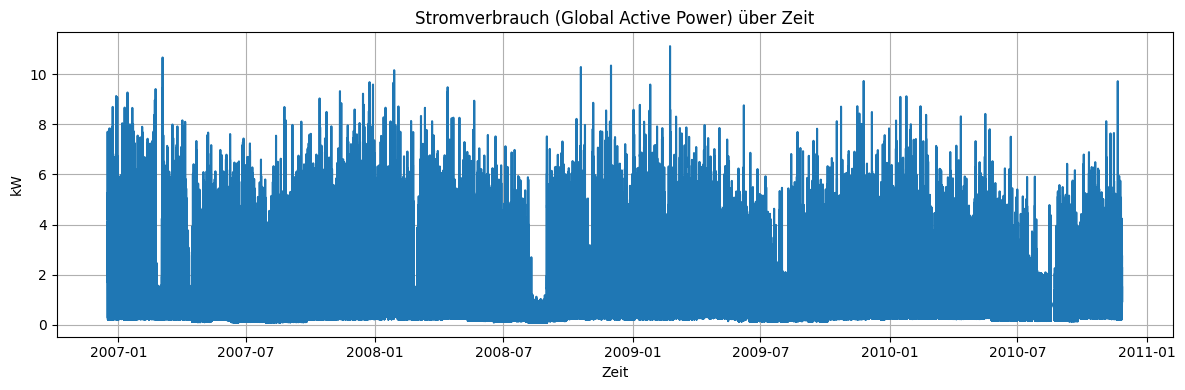

In [97]:
plot_line(
    df["Global_active_power"],
    title="Stromverbrauch (Global Active Power) über Zeit",
    ylabel="kW",
    xlabel="Zeit"
)


### Beobachtungen: Gesamtverlauf des Stromverbrauchs

- **Regelmäßige Tagesmuster:** Klar erkennbare Wiederholungen von Morgen- und Abendspitzen.  
- **Saisonale Muster:** Winterperioden zeigen deutlich höhere Verbrauchswerte als Sommermonate.  
- **Ausreißer:** Verbrauchsspitzen über **10 kW** treten selten auf – relevant für spätere Peak-Analysen.  
- **Datenlücken:** Größere Einbrüche 2008 und 2010 deuten auf **Messausfälle**, nicht auf echten Verbrauchsrückgang hin.
- **Langfristige Trends:** Verbrauch steigt leicht bis 2009 und sinkt anschließend im Jahr 2010.




# 2 Verteilung und Ausreißeranalyse
## 2.1 Histogramm


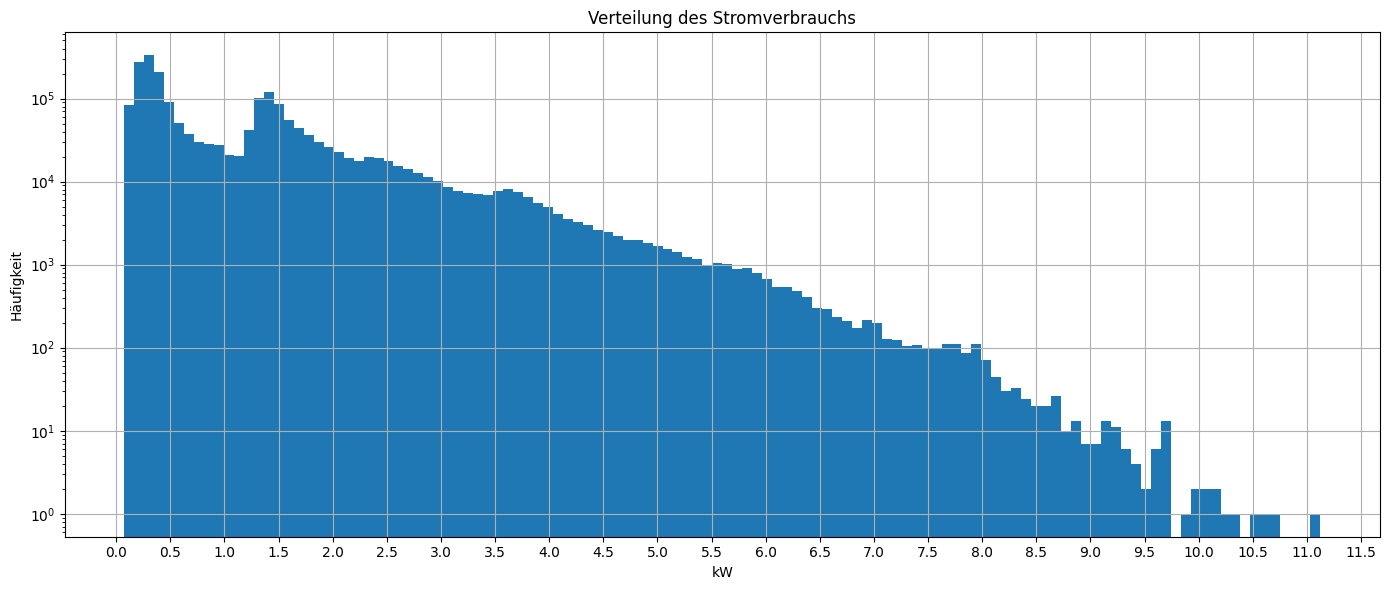

In [73]:
plt.figure(figsize=(14, 6))
plt.hist(df['Global_active_power'], bins=120, log=True)
# X-Achse in 0.2-kW-Schritten setzen
xmin, xmax = df['Global_active_power'].min(), df['Global_active_power'].max()
plt.xticks(np.arange(0, xmax + 0.5, 0.5))
plt.title("Verteilung des Stromverbrauchs")
plt.xlabel("kW")
plt.ylabel("Häufigkeit")
plt.tight_layout()
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\stromverteil_hist.png", dpi=300)
plt.show()




### Beobachtungen: Verteilung des Stromverbrauchs (Histogramm)
- Die meisten Werte liegen zwischen **0.2 und 0.6 kW** → typischer kontinuierlicher Haushaltsverbrauch.
- Ein kleiner zweiter Bereich um 1–1.5 kW zeigt alltägliche Nutzungsphasen wie Kochen oder Gerätebetrieb.
- Hohe Lastspitzen (>4 kW) sind selten und können auf außergewöhnliche Ereignisse oder große Verbraucher hindeuten.
- Keine Normalverteilung: Die Verteilung ist stark rechtschief → klassische z-score-Outlier-Methoden ungeeignet.
- Für spätere Anomalieerkennung eignen sich robustere Modelle wie Isolation Forest oder LOF.

## 2.2 Boxplot

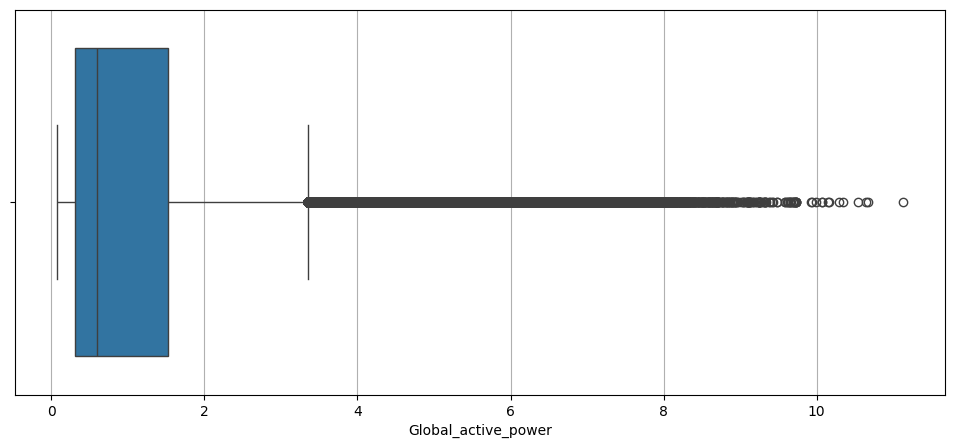

In [74]:
sns.boxplot(x=df['Global_active_power'])
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\boxplot.png", dpi=300)
plt.show()


### Beobachtungen: Boxplot des Stromverbrauchs

- Der Boxplot zeigt viele Ausreißer oberhalb von ca. 3 kW, was die starke Variabilität des Verbrauchs verdeutlicht.
- Der Median liegt deutlich unter dem oberen Quartil, was die Konzentration der Werte im niedrigen Bereich bestätigt.
- Einzelne Extremwerte über 10 kW fallen klar als Ausreißer auf und sind wichtig für spätere Peak- und Anomalieerkennung.


# 3. Tages-, Wochen- und Jahresmuster
## 3.1 Tages-/Wochen-Heatmap

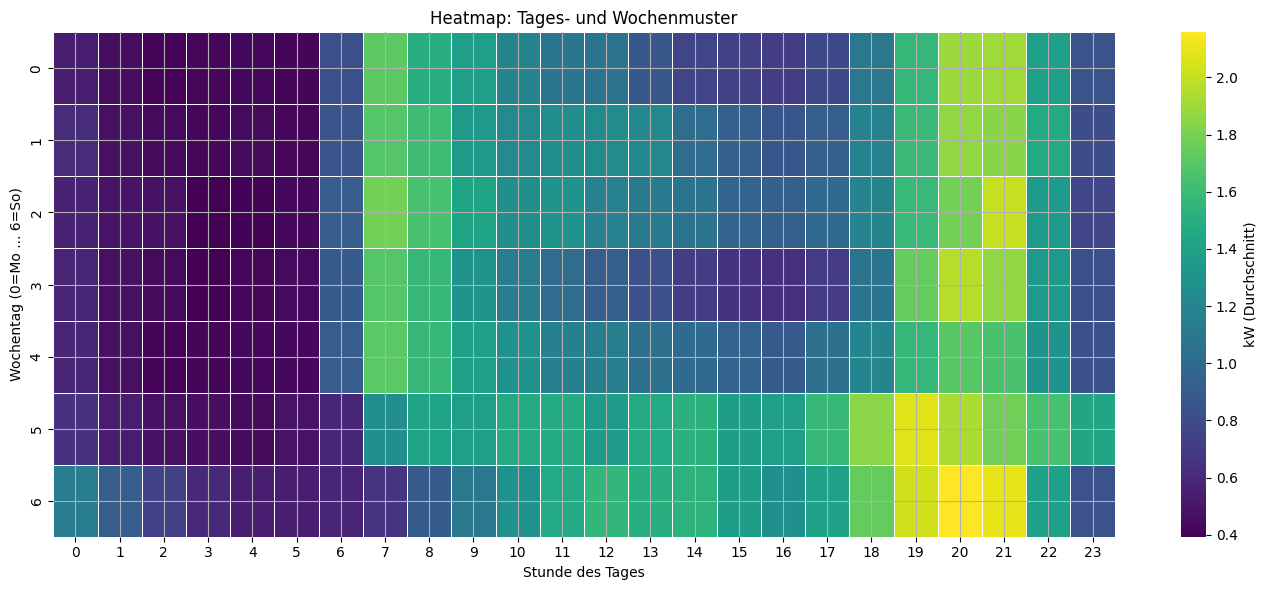

In [75]:
df['hour'] = df.index.hour
df['weekday'] = df.index.dayofweek

pivot = df.pivot_table(
    index='weekday',
    columns='hour',
    values='Global_active_power',
    aggfunc='mean'
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot, 
    cmap='viridis',
    cbar_kws={'label': 'kW (Durchschnitt)'},
    linewidths=0.5
)
plt.title("Heatmap: Tages- und Wochenmuster")
plt.xlabel("Stunde des Tages")
plt.ylabel("Wochentag (0=Mo ... 6=So)")
plt.tight_layout()
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\heatmap.png", dpi=300)
plt.show()

### Beobachtungen: Tages- und Wochenmuster (Heatmap)

- Morgens (7–10 Uhr) steigt der Verbrauch deutlich an, am Wochenende etwas später.
- Mittags sind Werktage niedriger, Wochenenden bleiben gleichmäßig höher.
- Abends (18–22 Uhr) entstehen die stärksten Verbrauchsspitzen.
- Nachts (0–5 Uhr) liegt ein stabiles Grundlastniveau vor.
- Wochenenden zeigen spätere Morgenpeaks und insgesamt höhere Tageswerte.

#### Relevanz

- Diese Muster sind normales Verhalten und sollten nicht als Anomalien gewertet werden.
- Features wie is_weekend, Stunde und Grundlast sind hilfreich für Modelle.


## 3.2 Jahr-zu-Jahr Vergleich

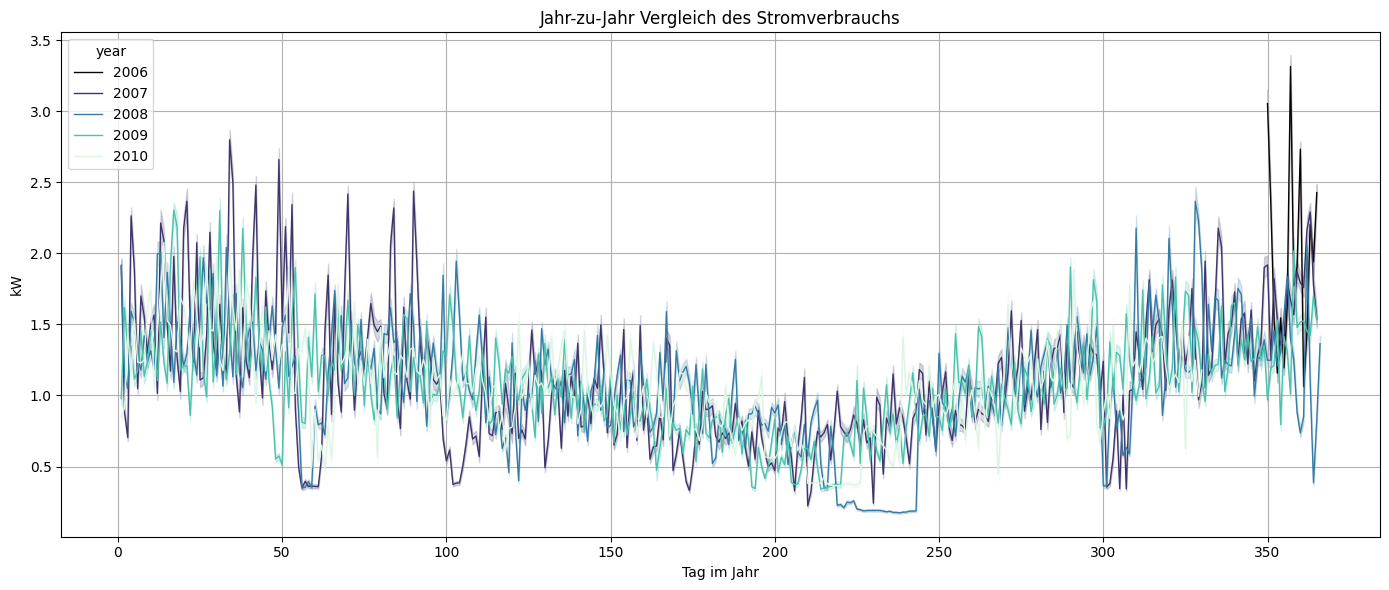

In [ ]:
df['hour'] = df.index.hour
df['weekday'] = df.index.dayofweek

pivot = df.pivot_table(
    index='weekday',
    columns='hour',
    values='Global_active_power',
    aggfunc='mean'
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot, 
    cmap='viridis',
    cbar_kws={'label': 'kW (Durchschnitt)'},
    linewidths=0.5
)
plt.title("Heatmap: Tages- und Wochenmuster")
plt.xlabel("Stunde des Tages")
plt.ylabel("Wochentag (0=Mo ... 6=So)")
plt.tight_layout()
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\heatmap.png", dpi=300)
plt.show()


### Beobachtungen: Jahr-zu-Jahr Vergleich
- Die saisonalen Muster wiederholen sich jedes Jahr: höherer Verbrauch im Winter, niedriger im Sommer.
- Einige Jahre unterscheiden sich leicht im Gesamtniveau (z. B. 2010 niedriger), und einzelne Messlücken sind sichtbar.
- Für Forecasting und Anomalieerkennung ist wichtig: Saisonale Schwankungen sind normal, Messausfälle dagegen keine echten Verbrauchsänderungen.

# 4. Verbrauchsprofile nach Zeitaggregation
## 4.1 Tagesmittelwerte

In [77]:
# Durchschnittlicher Verbrauch pro Stunde über alle Tage
hourly_profile = df.groupby('hour')['Global_active_power'].mean()

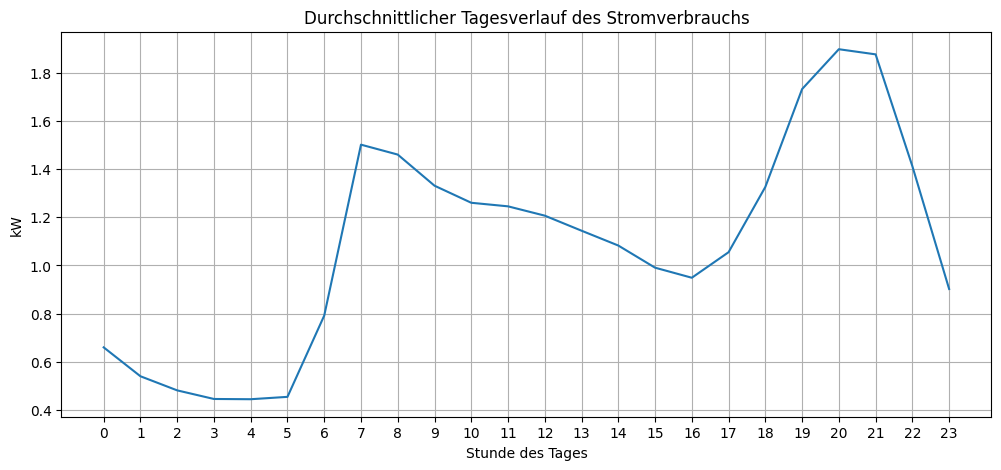

In [78]:
hourly_profile.plot(figsize=(12,5))
plt.title("Durchschnittlicher Tagesverlauf des Stromverbrauchs")
plt.xticks(range(24))
plt.xlabel("Stunde des Tages")
plt.ylabel("kW")
plt.grid(True)
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\durch_tageslauf.png", dpi=300)
plt.show()


### Beobachtungen: Durchschnittlicher Tagesverlauf
- **0–5 Uhr:** Sehr niedrige, stabile Grundlast.
- **6–9 Uhr:** Deutlicher Morgenpeak durch typische Haushaltsaktivitäten.
- **10–15 Uhr:** Ruhige Phase mit geringem Verbrauch, besonders an Werktagen.
- **17–21 Uhr:** Stärkster Tagespeak durch Kochen, Geräte und Beleuchtung.
- **22–24 Uhr:** Rückgang zum Grundlastniveau.

#### Relevanz
- Diese Muster bilden das „normale“ Verbrauchsprofil und dürfen nicht als Anomalien gewertet werden.
- Grundlast und Peakzeiten dienen als Referenz für spätere Anomalieerkennung.


## 4.2 Rolling 30-Tage-Mittel (Langfristige Trends)
Um saisonale Muster und langfristige Verbrauchsänderungen sichtbar zu machen, wird der tägliche Mittelwert mit einem 30-Tage-Fenster geglättet.

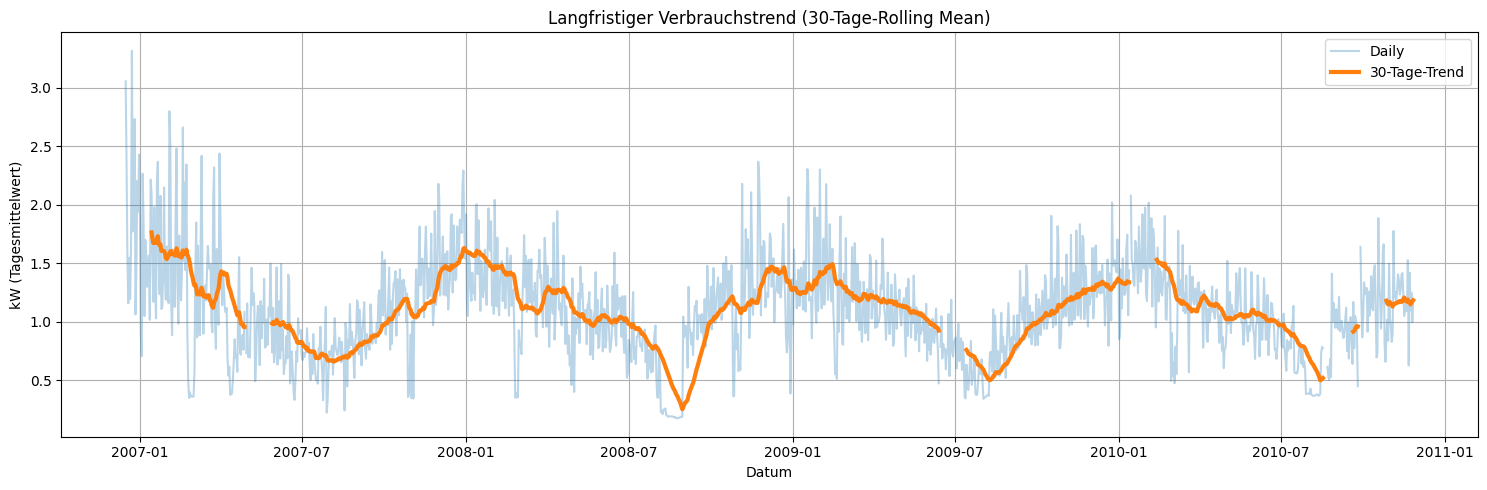

In [79]:
# 30-Tage-Rolling Mean
df_daily = df['Global_active_power'].resample('D').mean()

df_daily_rolling = df_daily.rolling(window=30, center=False).mean()

plt.figure(figsize=(15, 5))
plt.plot(df_daily, alpha=0.3, label="Daily")
plt.plot(df_daily_rolling, linewidth=3, label="30-Tage-Trend")

plt.xlabel("Datum")
plt.ylabel("kW (Tagesmittelwert)")
plt.title("Langfristiger Verbrauchstrend (30-Tage-Rolling Mean)")
plt.legend()
plt.tight_layout()
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\lang_verbrauch_30_t_r.png", dpi=300)
plt.show()


### Beobachtungen aus dem 30-Tage-Trend

- **Klar ausgeprägte Saisonalität:** Höherer Verbrauch im Winter, deutlich niedrigere Werte im Sommer.
- **Wiederkehrende Jahreszyklen:** Winterpeaks treten regelmäßig zwischen Dezember und Februar auf.
- **Sommerliche Verbrauchsminima:** Besonders 2008, 2009 und 2010 mit deutlich niedrigerem Energiebedarf.
- **Trendveränderung 2010:** Das gesamte Jahr zeigt einen sichtbaren Abwärtstrend → möglicher Gerätewechsel oder verändertes Verhalten.
- **Glättungseffekt:** Der Rolling Mean reduziert Tagesrauschen und macht Messlücken weniger dominant.



## 5. Tages- und Wochenprofile

Ziele:
- Typische Tagesverläufe (0–23 Uhr) verstehen
- Unterschiede zwischen Werktagen und Wochenenden erkennen

In [80]:
# Neue Spalten für Stunde und Wochentag
# Hinweis: Der Index ist bereits ein DatetimeIndex

df['hour'] = df.index.hour
df['weekday'] = df.index.dayofweek

### 5.2 Werktage vs. Wochenende

In [81]:
# Werktage: Montag (0) bis Freitag (4)
weekday_profile = (
    df[df['weekday'] < 5]
    .groupby('hour')['Global_active_power']
    .mean()
)


In [82]:
# Wochenende: Samstag (5) und Sonntag (6)
weekend_profile = (
    df[df['weekday'] >= 5]
    .groupby('hour')['Global_active_power']
    .mean()
)


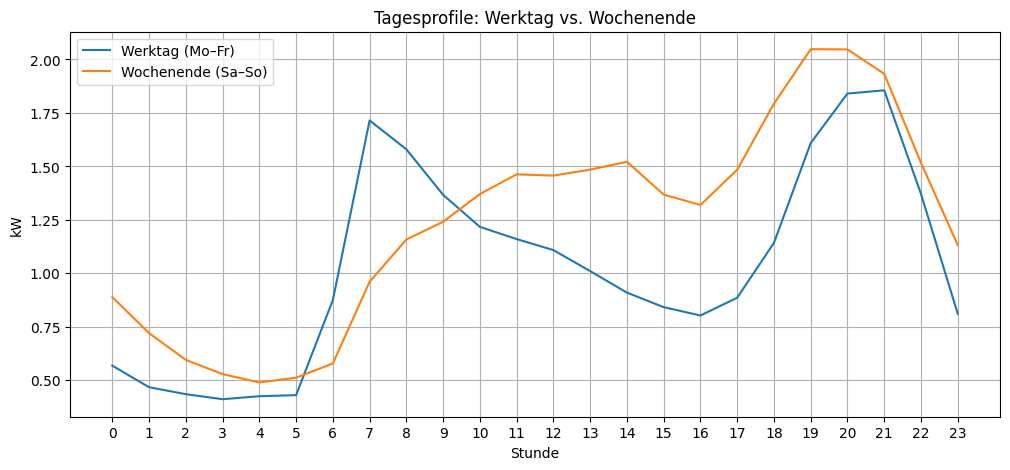

In [83]:
plt.figure(figsize=(12,5))

plt.plot(weekday_profile, label="Werktag (Mo–Fr)")
plt.plot(weekend_profile, label="Wochenende (Sa–So)")

plt.xticks(range(24))
plt.title("Tagesprofile: Werktag vs. Wochenende")
plt.xlabel("Stunde")
plt.ylabel("kW")
plt.legend()
plt.grid(True)
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\werktag_wochenende.png", dpi=300)
plt.show()


###  Beobachtungen: Tagesprofile – Werktag vs. Wochenende
- Die Grundlast in der Nacht ist an allen Tagen ähnlich, am Wochenende leicht höher.
- **Morgenpeak:** Werktage steigen früher und stärker an; Wochenenden beginnen später in den Tag.
- **Mittagszeit:** Werktage zeigen geringere Last durch Abwesenheit, Wochenende bleibt höher.
- **Abendpeak:** Auf beiden Profilen stärkste Spitze, am Wochenende später und ausgeprägter.
- **Später Abend:** Wochenende bleibt länger auf höherem Niveau.

#### Relevanz
- ML-Modelle müssen diese Unterschiede kennen, damit Wochenendmuster nicht als Anomalien gewertet werden.
- Nützliche Features: is_weekend, Stunde (hour).

## 6. Saisonale Muster

Ziele:
- Trends und längerfristige Muster erkennen
- Wöchentliche und monatliche Verbrauchsverläufe betrachten
- Gleitende Durchschnitte und Volatilität analysieren


### 6.2 Monatlicher Verbrauch

In [84]:
monthly_consumption = df['Global_active_power'].resample('M').mean()


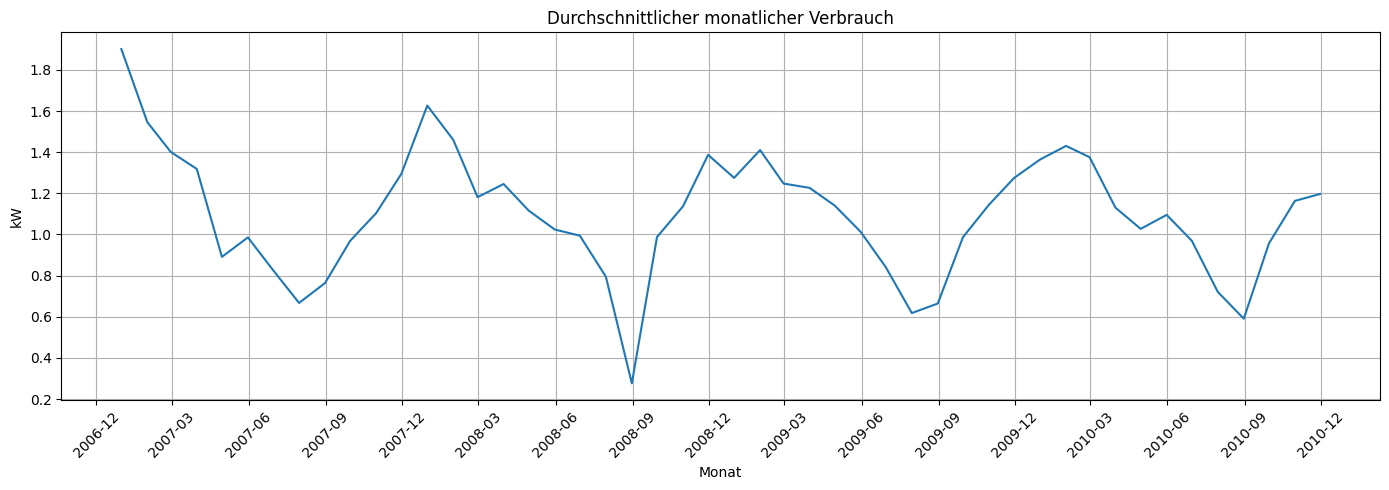

In [85]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_consumption)

ax.set_title("Durchschnittlicher monatlicher Verbrauch")
ax.set_xlabel("Monat")
ax.set_ylabel("kW")

# --- X-Achse verbessern ---
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # alle 3 Monate
plt.xticks(rotation=45)



ax.grid(True)
plt.tight_layout()
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\durch_monat_verbrauch.png", dpi=300)
plt.show()



###  Beobachtungen: Durchschnittlicher monatlicher Verbrauch
- Deutliches **saisonales Muster:** höhere Werte im Winter, niedrigere im Sommer.
- **Wintermonate** zeigen die höchsten Verbräuche (oft >1.4 kW).
- **Sommermonate** liegen meist zwischen 0.6–0.9 kW, mit einzelnen sehr niedrigen Werten durch Messlücken.
- Leichter Verbrauchsrückgang ab 2010 deutet auf verändertes Verhalten oder effizientere Geräte hin.

#### Relevanz
- Saisonale Muster müssen in Anomalie- und Forecasting-Modellen berücksichtigt werden.
- Monatswerte eignen sich gut für Trendanalysen und Dashboards.


## 7. Peak Detection (ohne Machine Learning)

Ziele:
- Extreme Verbrauchsspitzen identifizieren
- Baseline für spätere Anomalie-Modelle (Isolation Forest etc.)



### 7.1 Top-1% Verbrauchswerte als Peaks

In [86]:
# 7.2 Top-1%-Peaks (oberstes 1%-Quantil)

threshold_top1 = df["Global_active_power"].quantile(0.99)
df["top1_peak"] = df["Global_active_power"] > threshold_top1

print("Schwelle für Top-1%-Peaks:", threshold_top1)
print("Anzahl Top-1%-Peaks:", df["top1_peak"].sum())
df[["Global_active_power", "top1_peak"]].head()



Schwelle für Top-1%-Peaks: 4.85
Anzahl Top-1%-Peaks: 20473


,Global_active_power,top1_peak
Datetime,,
2006-12-16 17:24:00,4.216,False
2006-12-16 17:25:00,5.360,True
2006-12-16 17:26:00,5.374,True
2006-12-16 17:27:00,5.388,True
2006-12-16 17:28:00,3.666,False


In [87]:
# Beispiel: erster Zeitraum (z.B. 5 Tage – je nach Samplingrate anpassen)
ausschnitt = df.iloc[:5 * 24 * 60]  # falls 1-Minuten-Daten


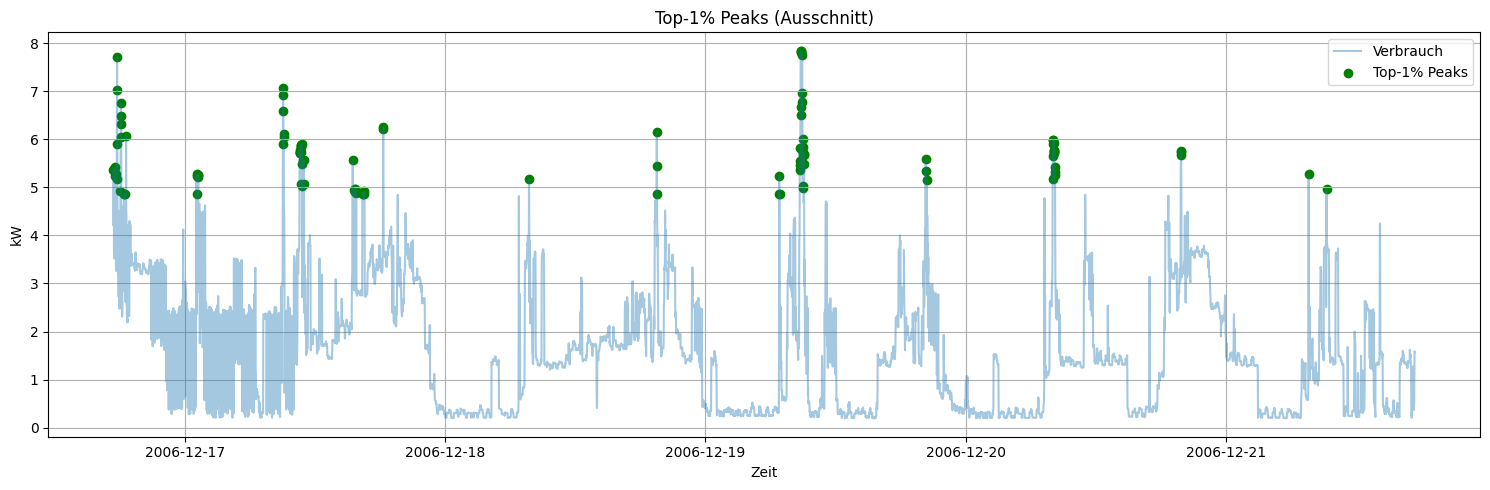

In [88]:
plt.figure(figsize=(15, 5))

# Verbrauch im Ausschnitt
plt.plot(ausschnitt["Global_active_power"], alpha=0.4, label="Verbrauch")

# Nur die Zeilen im Ausschnitt, wo top1_peak == True
peaks = ausschnitt[ausschnitt["top1_peak"]]

plt.scatter(
    peaks.index,
    peaks["Global_active_power"],
    color="green",
    label="Top-1% Peaks"
)

plt.title("Top-1% Peaks (Ausschnitt)")
plt.xlabel("Zeit")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\top_peak.png", dpi=300)
plt.show()


###  Beobachtungen: Top-1% Peaks (Ausschnitt)

- Die Top-1% Methode markiert die **absolut höchsten Verbrauchswerte** im Datensatz.
- Die meisten Spitzen liegen im Bereich **5–8 kW**, deutlich über dem normalen Tagesverbrauch.
- Peaks treten häufig morgens und abends auf → typische Hochlastzeiten im Haushalt.
- Die Methode identifiziert zuverlässig wenige, aber sehr starke Lastspitzen.
- Im Vergleich zum Z-Score erkennt diese Methode **globale Extremwerte**, während der Z-Score **lokale Ausreißer** hervorhebt.


## 8. Korrelationsanalyse der Energievariablen

Ziel:
- Beziehungen zwischen den verschiedenen Messgrößen verstehen
- Relevante Features für spätere Modelle identifizieren


In [89]:
corr_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

corr_matrix = df[corr_cols].corr()
corr_matrix


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.247017,-0.399762,0.998889,0.484401,0.434569,0.638555
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120,0.123111,0.139231,0.089617
Voltage,-0.399762,-0.112246,1.000000,-0.411363,-0.195976,-0.167405,-0.268172
Global_intensity,0.998889,0.266120,-0.411363,1.000000,0.489298,0.440347,0.626543
Sub_metering_1,0.484401,0.123111,-0.195976,0.489298,1.000000,0.054721,0.102571
Sub_metering_2,0.434569,0.139231,-0.167405,0.440347,0.054721,1.000000,0.080872
Sub_metering_3,0.638555,0.089617,-0.268172,0.626543,0.102571,0.080872,1.000000


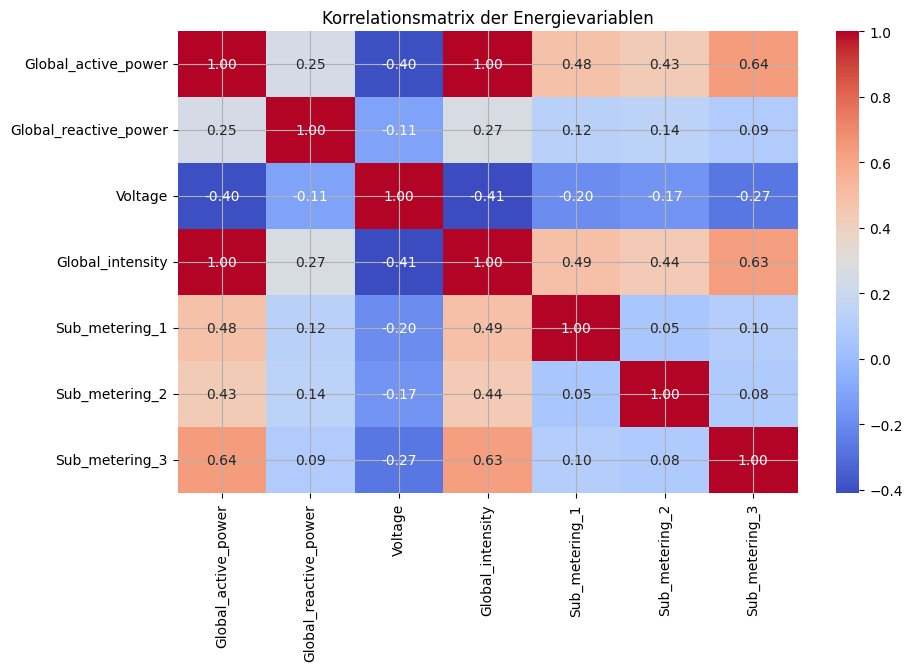

In [92]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelationsmatrix der Energievariablen")
plt.savefig("C:\\Users\\NataliaArchipenko\\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\\Desktop\\Projekt\\Img\\eda\\kor_matrix.png", dpi=300)
plt.show()


###  Beobachtungen: Korrelationsmatrix der Energievariablen
- Global_active_power und Global_intensity sind nahezu identisch korreliert (1.00) → eine der beiden Variablen ist redundant.
- Sub_metering_3 zeigt die stärkste Beziehung zum Gesamtverbrauch → wichtiger Treiber für Lastspitzen.
- Sub_metering_1 und 2 sind nur schwach korreliert → sie erfassen unterschiedliche Verbrauchergruppen und liefern zusätzliche Informationen.
- Voltage ist kaum korreliert → für Verbrauchs- oder Anomalieanalysen weniger relevant.
- Global_reactive_power korreliert nur moderat → kann für bestimmte Geräteinformationen nützlich sein.
#### Relevanz
- Redundante Variablen vermeiden (active_power vs. intensity).
- Sub_metering_3 als wichtiges Feature für Peaks/Anomalien nutzen.
- Voltage optional weglassen, falls das Modell empfindlich auf irrelevante Features reagiert.

## 9. Fazit der EDA (optimierte Version)
- Der Stromverbrauch zeigt klare **tägliche Muster** mit typischen Morgen- und Abendspitzen.
- **Werktage und Wochenenden** unterscheiden sich deutlich im Verbrauchsverlauf.
- **Saisonale Trends** (Monats- und Jahresmuster) zeigen höhere Verbräuche im Winter und niedrigere im Sommer.
- Die **Top-1%-Peak-Analyse** liefert nachvollziehbare extreme Verbrauchsereignisse als Vorstufe zur Anomalieerkennung.
- Die **Korrelationsanalyse** zeigt starke Zusammenhänge zwischen Gesamverbrauch und Global_intensity sowie wichtige Beiträge der Sub-Metering-Kanäle.

#### Relevanz für Phase 3
- Die identifizierten Muster dienen als Basis für ML-Modelle, um normale vs. ungewöhnliche Verbräuche zu unterscheiden.
- Peak-Labels, saisonale Features und Wochentagsinformationen verbessern die Modellqualität.

